# Trader Performance vs Market Sentiment Analysis

## Objective
Analyze how market sentiment (Fear/Greed) influences trader behavior and performance on Hyperliquid, and derive actionable trading insights.

## Data Loading

In [35]:
import pandas as pd

# load datasets
sentiment = pd.read_csv("data/fear_greed_index.csv")
trader = pd.read_csv("data/historical_data.csv")

print("Datasets loaded successfully")

Datasets loaded successfully


In [36]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [37]:
trader.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


## Data Preparation & Date Alignment

In [38]:
print("Sentiment columns:")
print(sentiment.columns)

print("\nTrader columns:")
print(trader.columns)

Sentiment columns:
Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

Trader columns:
Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')


In [39]:
print(trader.columns)


Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')


## Data Preparation & Date Alignment

In [40]:
trader['Timestamp IST'] = pd.to_datetime(
    trader['Timestamp IST'],
    dayfirst=True
)

In [41]:
trader['date'] = trader['Timestamp IST'].dt.date
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date

In [42]:
print(sentiment.columns)

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


In [43]:
print(sentiment.columns)

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


In [44]:
df = trader.merge(
    sentiment[['date', 'classification']],
    on='date',
    how='left'
)

In [45]:
df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed


In [46]:
df.groupby('classification')['Closed PnL'].mean()

classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64

## Analysis 1 — Trader Performance vs Sentiment

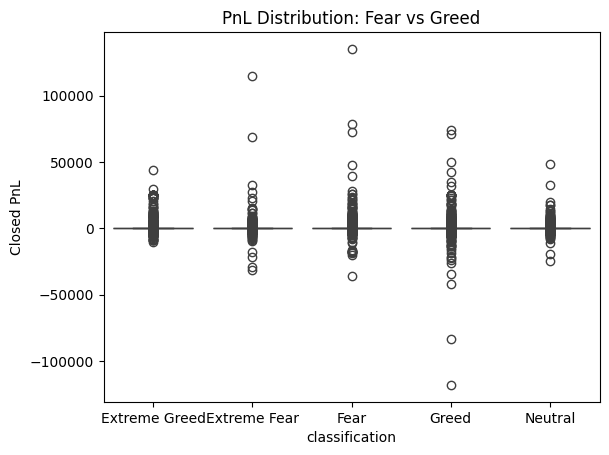

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df, x='classification', y='Closed PnL')
plt.title("PnL Distribution: Fear vs Greed")
plt.show()

**Observation:**  
Greed periods show slightly higher average profitability, while Fear phases display wider variability indicating higher uncertainty.

## Analysis 2 — Trading Activity

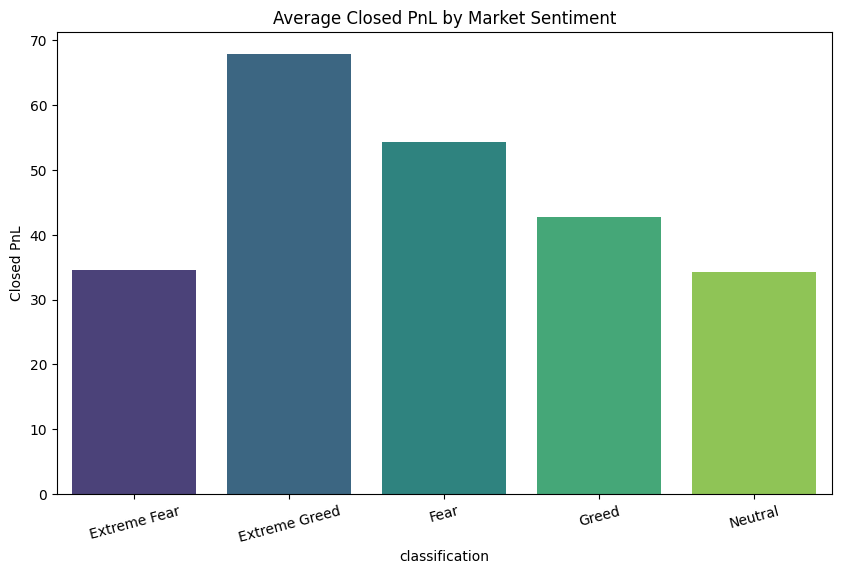

In [48]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=avg_pnl,
    x='classification',
    y='Closed PnL',
    hue='classification',
    palette='viridis',
    legend=False
)

plt.title("Average Closed PnL by Market Sentiment")
plt.xticks(rotation=15)
plt.show()

**Observation:**  
Trader profitability varies across market sentiment states, suggesting sentiment influences performance.


In [49]:
df['classification'].value_counts()

classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64

In [50]:
trade_count = df.groupby('classification').size().reset_index(name='num_trades')
trade_count

,classification,num_trades
0,Extreme Fear,21400
1,Extreme Greed,39992
2,Fear,61837
3,Greed,50303
4,Neutral,37686


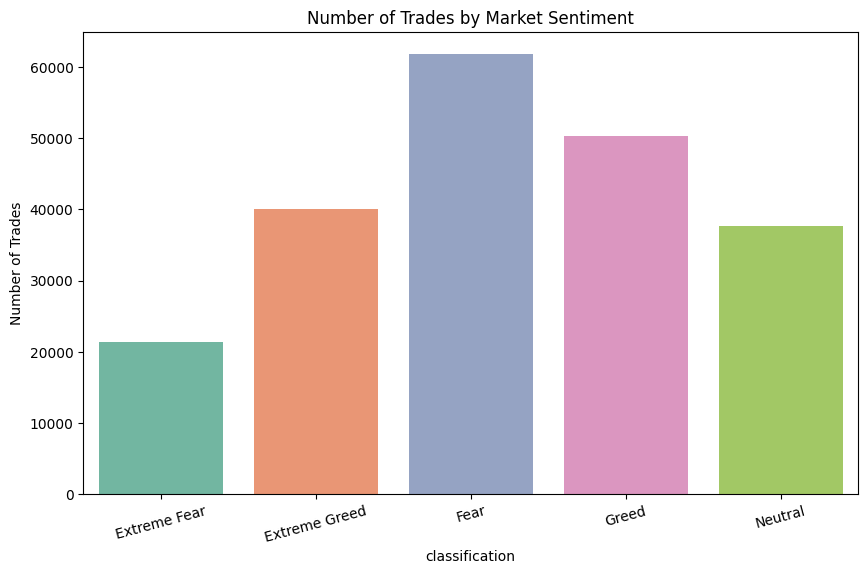

In [51]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=trade_count,
    x='classification',
    y='num_trades',
    hue='classification',
    palette='Set2',
    legend=False
)

plt.title("Number of Trades by Market Sentiment")
plt.ylabel("Number of Trades")
plt.xticks(rotation=15)
plt.show()

In [52]:
df['Side'].value_counts()

Side
SELL    108528
BUY     102696
Name: count, dtype: int64

In [53]:
side_analysis = (
    df.groupby(['classification', 'Side'])
    .size()
    .reset_index(name='count')
)

side_analysis

,classification,Side,count
0,Extreme Fear,BUY,10935
1,Extreme Fear,SELL,10465
2,Extreme Greed,BUY,17940
3,Extreme Greed,SELL,22052
4,Fear,BUY,30270
5,Fear,SELL,31567
6,Greed,BUY,24576
7,Greed,SELL,25727
8,Neutral,BUY,18969
9,Neutral,SELL,18717


## Analysis 3 — Long vs Short Behavior

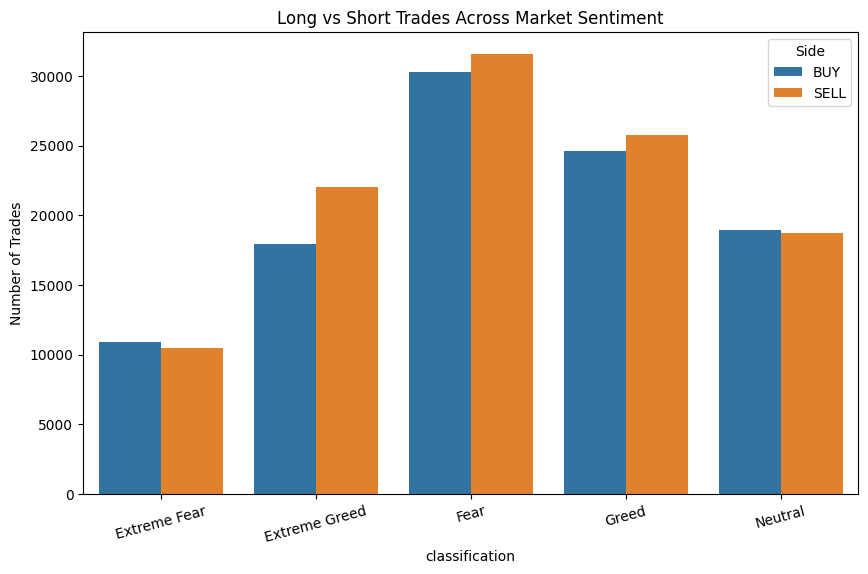

In [54]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=side_analysis,
    x='classification',
    y='count',
    hue='Side'
)

plt.title("Long vs Short Trades Across Market Sentiment")
plt.ylabel("Number of Trades")
plt.xticks(rotation=15)
plt.show()

**Observation:**  
Trading activity changes significantly during different sentiment phases, indicating behavioral shifts.

In [55]:
print(df.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'date', 'classification'],
      dtype='object')


In [56]:
print(df.columns)


Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'date', 'classification'],
      dtype='object')


In [57]:
avg_size = df.groupby('classification')['Size USD'].mean().reset_index()
avg_size

,classification,Size USD
0,Extreme Fear,5349.731843
1,Extreme Greed,3112.251565
2,Fear,7816.109931
3,Greed,5736.884375
4,Neutral,4782.732661


In [58]:
avg_size = df.groupby('classification')['Size USD'].mean().reset_index()
avg_size

,classification,Size USD
0,Extreme Fear,5349.731843
1,Extreme Greed,3112.251565
2,Fear,7816.109931
3,Greed,5736.884375
4,Neutral,4782.732661


## Analysis 4 — Trade Size (Risk Proxy)

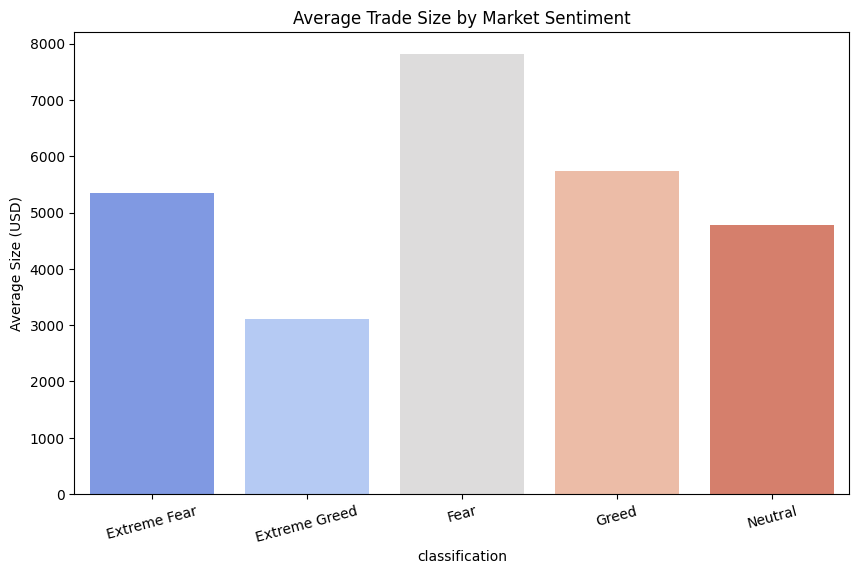

In [59]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=avg_size,
    x='classification',
    y='Size USD',
    hue='classification',
    palette='coolwarm',
    legend=False
)

plt.title("Average Trade Size by Market Sentiment")
plt.ylabel("Average Size (USD)")
plt.xticks(rotation=15)
plt.show()

**Observation:**  
Traders adjust position direction (BUY/SELL) and trade size depending on sentiment, reflecting changes in risk appetite.

## Conclusion

This analysis demonstrates that market sentiment influences trader behavior, trade direction, and performance.  
Understanding these patterns can help design sentiment-aware risk management and trading strategies.